In [1]:
import sys
import pickle
from pathlib import Path

import pandas as pd
import geopandas as gpd 
import numpy as np
import matplotlib as mp
import matplotlib.pyplot as plt

import config, data, models, train, evaluate

In [2]:
save_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/multigraph_manual")
metadata_dir = save_dir / "metadata"

subbasins = pd.read_parquet(metadata_dir / 'subbasins.parquet', columns=['site_id', 'uparea_km2', 'is_gauge', 'outlet_id'])
subbasins.index = subbasins.index.astype(str)

In [13]:
exp_root =  Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_q/")
target = 'discharge'

exp_dirs = {
    "ERA5": Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_q/era5_20251211_232808"),
    "ERA5 + SWOT": Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_q/swot_supervised_20251211_233150"),
}

exp_dirs

{'ERA5': PosixPath('/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_q/era5_20251211_232808'),
 'ERA5 + SWOT': PosixPath('/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_q/swot_supervised_20251211_233150')}

In [34]:
exp_root =  Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_spq/")
target = 'discharge'

exp_dirs = {
    "ERA5": Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_spq/era5_20251211_234214"),
    "ERA5 + SWOT": Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_spq/swot_supervised_20251211_234319"),
}
exp_dirs


{'ERA5': PosixPath('/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_spq/era5_20251211_234214'),
 'ERA5 + SWOT': PosixPath('/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_spq/swot_supervised_20251211_234319')}

In [29]:
def calc_discharge(df, subs):
    uparea = subs['uparea_km2'] 
    mapped_uparea = df.index.get_level_values('subbasin').map(uparea)
    
    df[('pred', 'discharge')] = df[('pred','unit_discharge')] * mapped_uparea
    df[('obs', 'discharge')] = df[('obs','unit_discharge')] * mapped_uparea
    return df

In [35]:
fig_dir = exp_root / "_figures"
fig_dir.mkdir(exist_ok=True, parents=True)

from tqdm import tqdm
import evaluate

exps = []
for exp_name, exp_dir in tqdm(exp_dirs.items()):
    try:
        results = pd.read_parquet(exp_dir / 'results' / 'test_results.parquet').dropna()

        if 'unit_discharge' in results['pred'].columns:
            results = calc_discharge(results, subbasins)

        bulk_m = evaluate.get_all_metrics(results)
        basin_m = evaluate.get_basin_metrics(results)
        
        # with open(exp_dir / 'results' / "test_metrics.pkl", 'rb') as f:
        #     bulk_m, basin_m = pickle.load(f)
        
        exps.append((exp_name, results, bulk_m, basin_m))
    except Exception as e:
        print(f"{exp_name}: {e}")
        pass

exps = sorted(exps, key=lambda x: x[0])

100%|██████████| 2/2 [00:27<00:00, 13.57s/it]


ERA5 KGE:  0.35
ERA5 + SWOT KGE:  0.37
ERA5 corr:  0.09
ERA5 + SWOT corr:  0.10
ERA5 alpha:  0.19
ERA5 + SWOT alpha:  0.16
ERA5 beta:  0.05
ERA5 + SWOT beta:  0.05


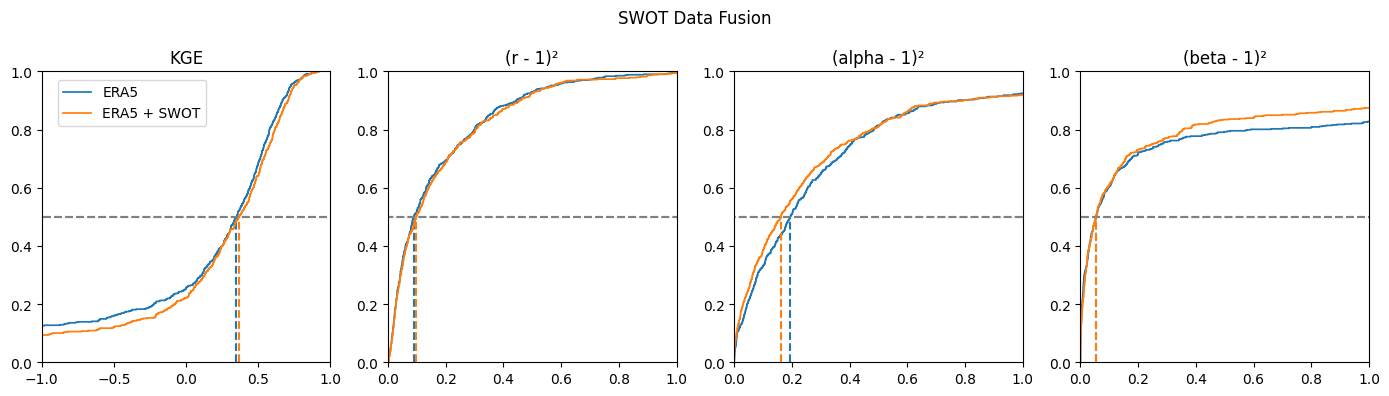

In [36]:
plt.close('all')

num_models = len(exps)

metric_names = {
    'KGE': 'KGE',
    'corr': '(r - 1)²',
    'alpha': '(alpha - 1)²',
    'beta': '(beta - 1)²'
}

lines = True

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes = axes.flatten()

for ax, (name, title) in zip(axes, metric_names.items()):
    for exp_name, results, bulk_metrics, basin_metrics in exps:
        x = np.array(basin_metrics[target][name], dtype=float)
        
        if name in ['alpha', 'beta', 'corr']:
            x = (x-1)**2
        
        
        x = x[~np.isnan(x)]
        line = ax.ecdf(x, linewidth=1.25, label=exp_name)

        median_val = np.median(x)
        print(f"{exp_name} {name}: {median_val: 0.2f}")

        if lines:
            line_color = line.get_color()
            ax.hlines(y=0.5, xmin=-100, xmax=100, 
                      colors='grey', linestyles='--', linewidth=1.5, alpha=1)
            ax.vlines(x=median_val, ymin=0, ymax=0.5, 
                      colors=line_color, linestyles='--', linewidth=1.5, alpha=1)
        
    
    ax.set_title(f"{title}")

axes[0].set_xlim([-1, 1])
axes[1].set_xlim([0, 1])
axes[2].set_xlim([0, 1])
axes[3].set_xlim([0, 1])

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.04, 0.82))

# fig.subplots_adjust(left=0.1, right=0.95, bottom=0.2, top=0.95, wspace=0.3, hspace=0.4)
plt.suptitle('SWOT Data Fusion')
plt.tight_layout()
plt.show()

file_name = "KGE_decomp" + ("_lines" if lines else "") + ".png"
# fig.savefig(fig_dir / file_name, dpi=300)

In [20]:
fig_dir

PosixPath('/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_no_decay/_figures')

In [6]:
import xarray as xr

basin_mask = (subbasins['outlet_id'] == 'USGS-07374000')
test_sub_mask = subbasins.index.isin(results.index.get_level_values('subbasin').unique())
basin_gauges = subbasins[basin_mask & test_sub_mask].index
basin_ds = xr.open_zarr("/scratch4/workspace/tlanghorst_umass_edu-swot-ml-zarr/zbs_batched/USGS-07374000")
gauge_ds = basin_ds.sel(subbasin=basin_gauges)


# ds = ds.sel(subbasin=reach_id, date=slice(start_date, end_date))
# has_swot_obs = ~np.isnan(ds['d_wse_river'].to_numpy())

In [7]:
gauge_swot_count = (~gauge_ds['d_wse_river'].to_dataframe().isna()).groupby('subbasin').apply(sum)
gauge_swot_count = gauge_swot_count.sort_values(by='d_wse_river')
gauge_swot_count.rename(columns={'d_wse_river':'num_swot_obs'}, inplace=True)

gauge_swot_count

/tmp/ipykernel_1326667/312708266.py:1: FutureWarning: The provided callable <built-in function sum> is currently using np.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string np.sum instead.
  gauge_swot_count = (~gauge_ds['d_wse_river'].to_dataframe().isna()).groupby('subbasin').apply(sum)
/nas/cee-water/cjgleason/ted/swot-ml/.venv/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


,num_swot_obs
subbasin,
ECCC-11AA025,0
USGS-06354050,0
USGS-06354000,0
USGS-06351200,0
USGS-06349000,0
...,...
USGS-06185500,66
USGS-06770200,69
USGS-06438500,76


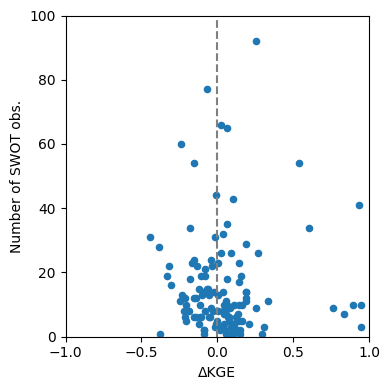

In [37]:
joined_kge = exps[0][3][target]['KGE'].rename('era5').to_frame().join(exps[1][3][target]['KGE'].rename('swot'))
joined_kge['d_kge'] = joined_kge['swot'] - joined_kge['era5'] 
joined_kge = joined_kge.join(gauge_swot_count)
joined_kge = joined_kge[joined_kge['num_swot_obs']>0]

plt.close('all')
fig, ax = plt.subplots(1, 1, figsize=(4,4))

joined_kge.plot.scatter('d_kge','num_swot_obs',ax=ax)
ax.vlines(x=0, ymin=0, ymax=100, color='grey', linestyles='--', linewidth=1.5, alpha=1)


plt.xlim([-1, 1])
plt.ylim([0, 100])
plt.xlabel("ΔKGE")
plt.ylabel("Number of SWOT obs.")
plt.tight_layout()
# fig.savefig(fig_dir / 'd_kge.png', dpi=300)

In [40]:
kge = exps[1][3][target]['KGE'].dropna().sort_values(ascending=False)

kge[kge>0]

USGS-06289000    0.913662
USGS-05357335    0.909476
USGS-03271620    0.901134
USGS-03098600    0.877534
USGS-03264000    0.864376
                   ...   
USGS-03250100    0.017634
USGS-03425622    0.016864
USGS-06307500     0.01551
USGS-06349000     0.00944
USGS-07176500    0.005607
Name: KGE, Length: 465, dtype: object

In [13]:
basin_id

'USGS-07374000'

In [55]:
has_swot_obs.sum()

66

11
ERA5: 0.63
ERA5 + SWOT: 0.67


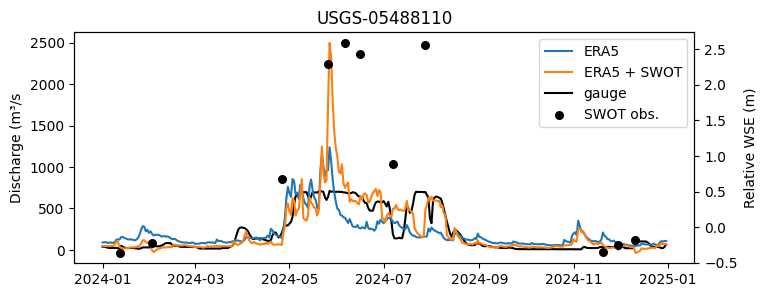

In [38]:
import xarray as xr

reach_id = 'USGS-05488110'
start_date = "2024-01-01"
end_date = "2024-12-31"
metric = 'KGE'

# Horrible hackishness
basin_id = subbasins.loc[reach_id]['outlet_id']
ds = xr.open_zarr(f"/scratch4/workspace/tlanghorst_umass_edu-swot-ml-zarr/zbs_batched/{basin_id}")
reach_ds = ds.sel(subbasin=reach_id, date=slice(start_date, end_date))
has_swot_obs = ~np.isnan(reach_ds['d_wse_river'].to_numpy())

print(np.sum(has_swot_obs))

fig, ax = plt.subplots(1, 1, figsize=(8, 3))




for exp_name, results, bulk_metrics, basin_metrics in exps: 
    xs = results.xs(reach_id, level='subbasin').sort_index()
    xs = xs.droplevel(0,0)
    xs = xs.loc[start_date:end_date]
    
    x = xs.index
    y = xs['pred'][target]
    plt.plot(x, y, label=exp_name)
    
    print(f"{exp_name}: {basin_metrics.loc[reach_id][target][metric]:0.2f}")
    
ax.plot(xs.index, xs['obs'][target], color='black', zorder=0, label='gauge')

plt.ylabel("Discharge (m³/s")

ax2 = ax.twinx()  # shares x axis but has its own y axis
date = reach_ds.date.values
d_wse = reach_ds['d_wse_river'].values 
ax2.scatter(date, d_wse, color='black', marker='o', s=30, zorder=10, label='SWOT obs.')
plt.ylabel("Relative WSE (m)")


handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
# Combine them
handles = handles1 + handles2
labels = labels1 + labels2
ax.legend(handles, labels, loc='best')


plt.title(reach_id)

plt.show()
# fig.savefig(fig_dir / f"timeseries_{reach_id}.png", dpi=300)

In [42]:
gauge_swot_count = gauge_swot_count.sort_values(by='num_swot_obs', ascending=False)

In [106]:

reach_ds = ds.sel(subbasin=reach_id, date=slice(start_date, end_date))
date = reach_ds.date.values
d_wse = reach_ds['d_wse_river'].values
# plt.scatter(date,d_wse)

USGS-06329500: 92
ERA5: 0.09
ERA5 + SWOT: 0.34


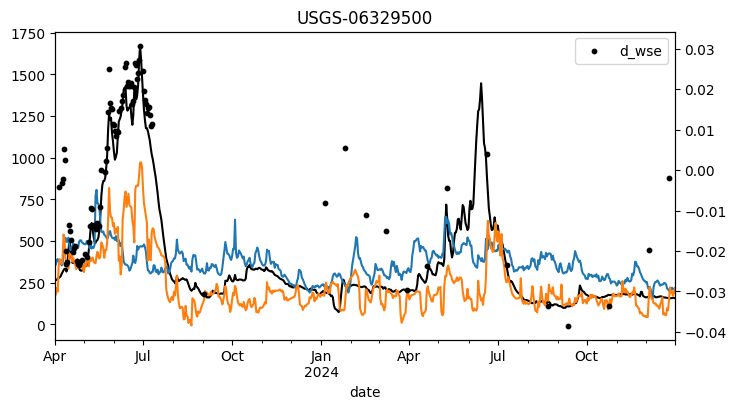

USGS-06799000: 77
ERA5: 0.30
ERA5 + SWOT: 0.24


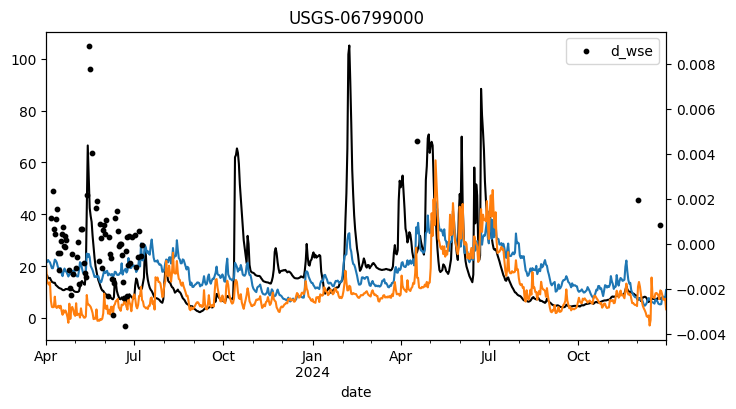

USGS-06438500: 76
ERA5: -2.96
ERA5 + SWOT: -0.11


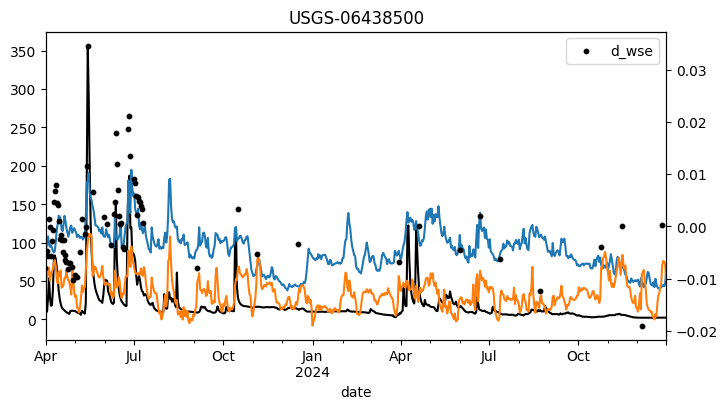

USGS-06770200: 69
ERA5: -6.66
ERA5 + SWOT: -1.71


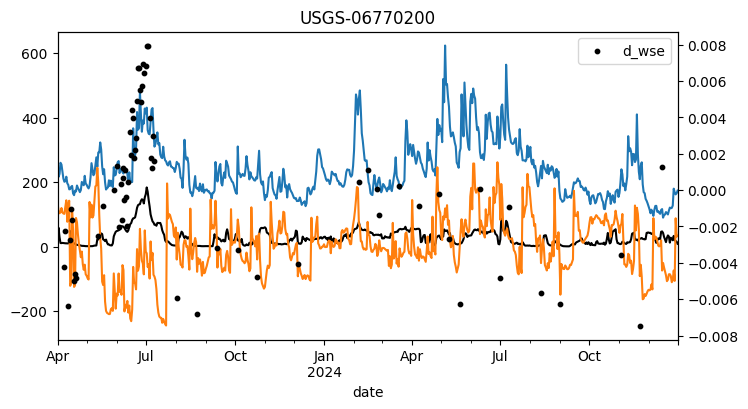

USGS-06185500: 66
ERA5: 0.19
ERA5 + SWOT: 0.22


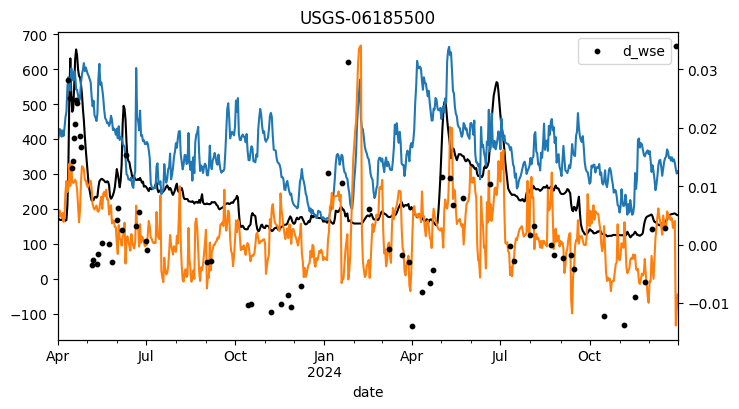

USGS-06287800: 65
ERA5: 0.49
ERA5 + SWOT: 0.56


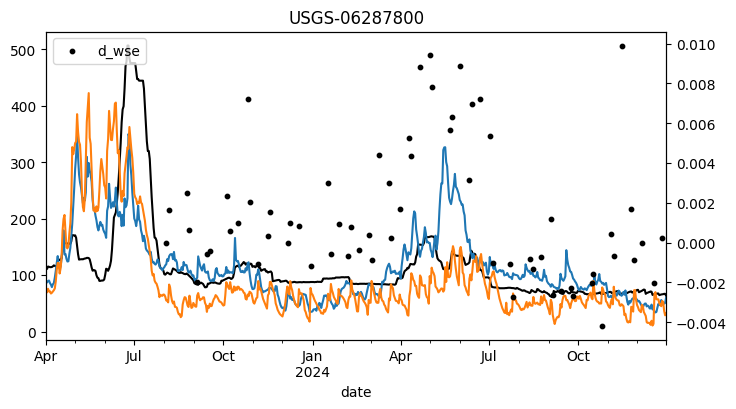

USGS-06777495: 60
ERA5: 0.15
ERA5 + SWOT: -0.09


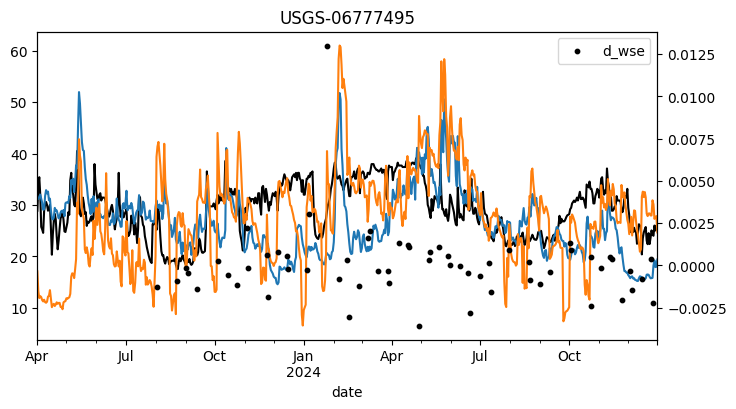

USGS-06336000: 58
ERA5: -3.70
ERA5 + SWOT: -0.93


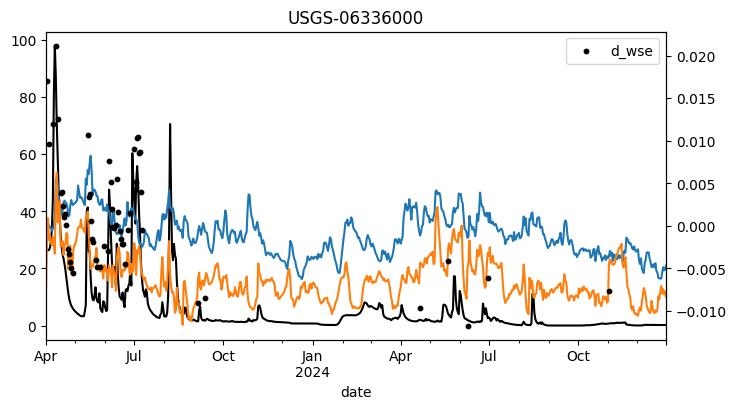

USGS-03294500: 54
ERA5: 0.50
ERA5 + SWOT: 0.34


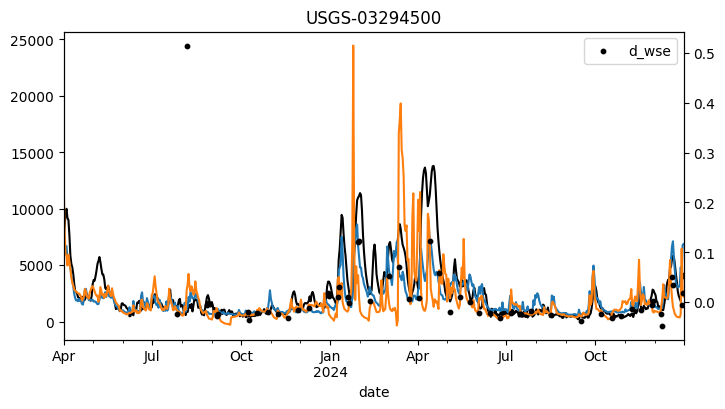

USGS-06446500: 54
ERA5: -0.61
ERA5 + SWOT: -0.07


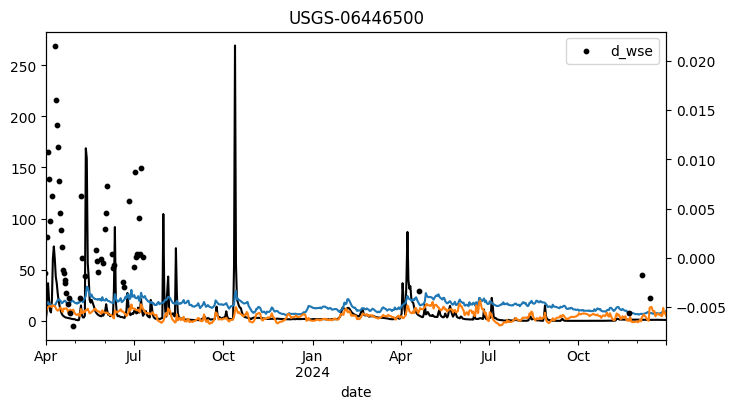

USGS-05355250: 53
ERA5: 0.51
ERA5 + SWOT: -1.54


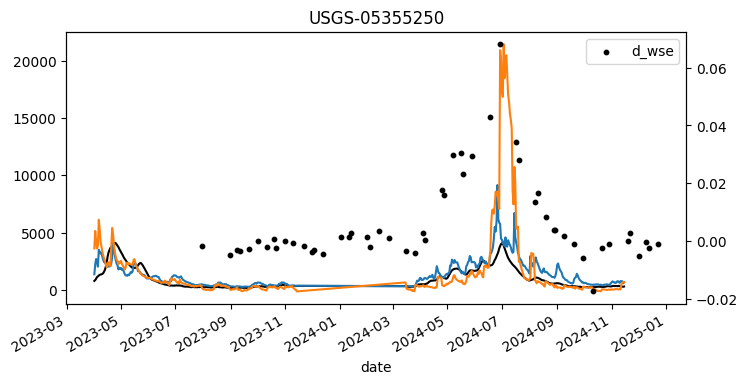

USGS-06040000: 44
ERA5: 0.46
ERA5 + SWOT: 0.45


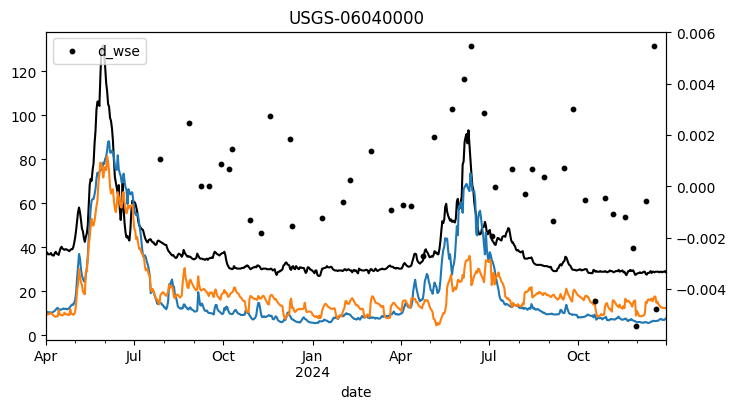

USGS-03292494: 43
ERA5: 0.41
ERA5 + SWOT: 0.52


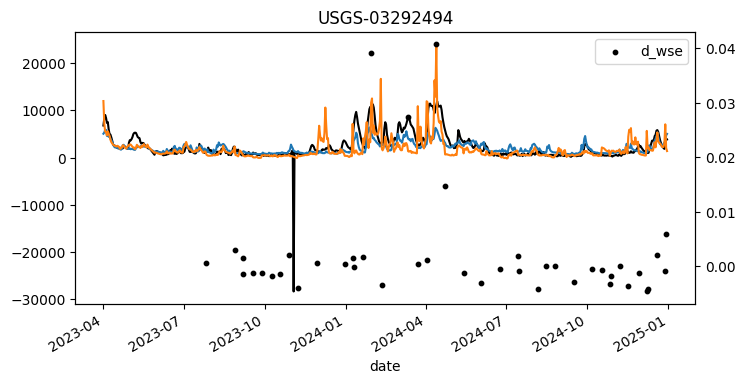

USGS-06801000: 41
ERA5: -0.51
ERA5 + SWOT: 0.42


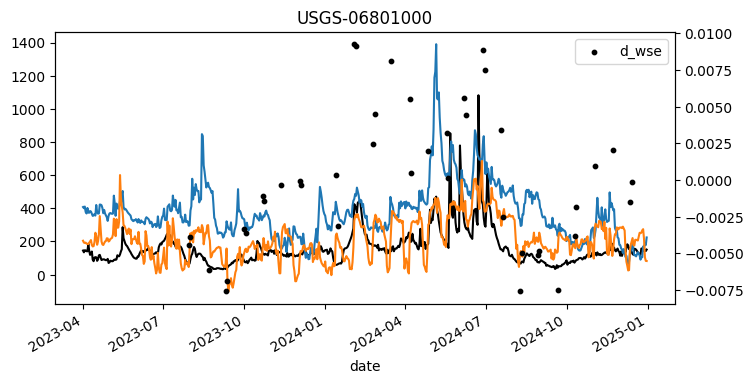

USGS-05344490: 35
ERA5: 0.35
ERA5 + SWOT: 0.41


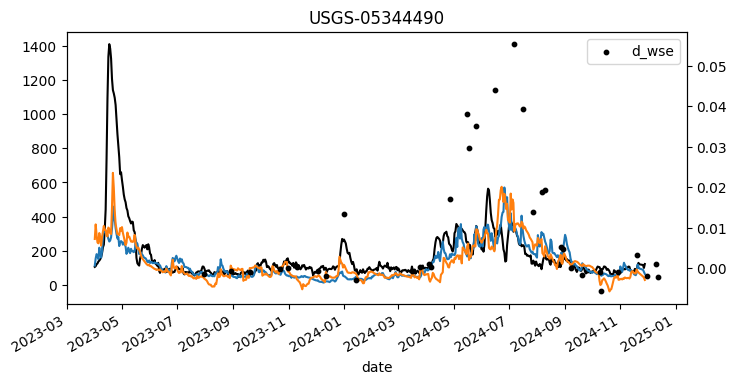

USGS-06324500: 34
ERA5: -0.55
ERA5 + SWOT: 0.05


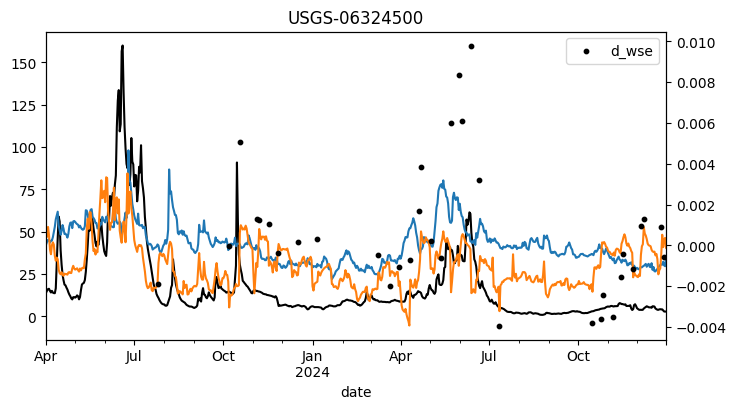

USGS-05369500: 34
ERA5: 0.58
ERA5 + SWOT: 0.40


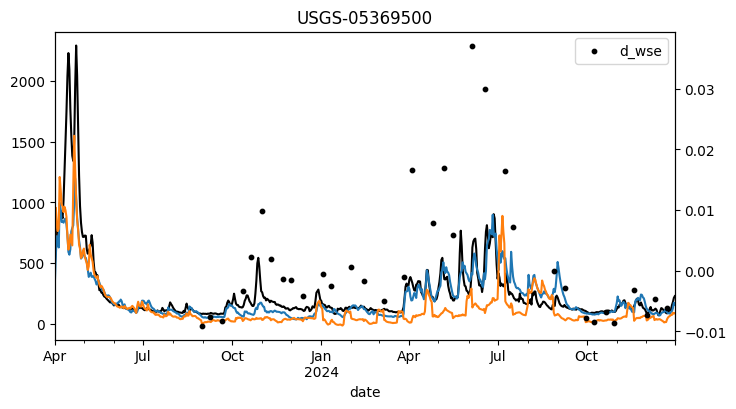

USGS-05344500: 32
ERA5: 0.69
ERA5 + SWOT: 0.73


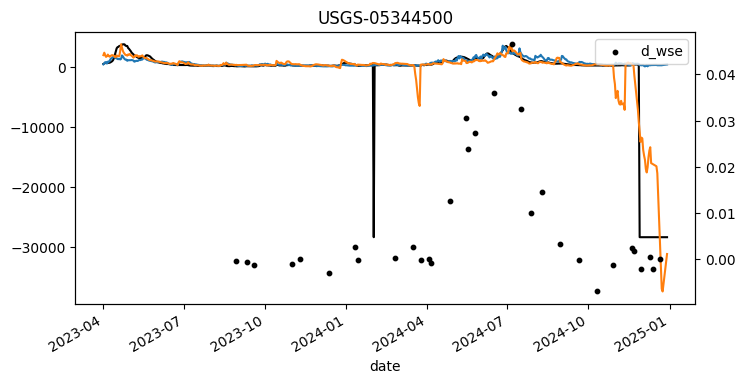

USGS-07060500: 31
ERA5: 0.31
ERA5 + SWOT: 0.30


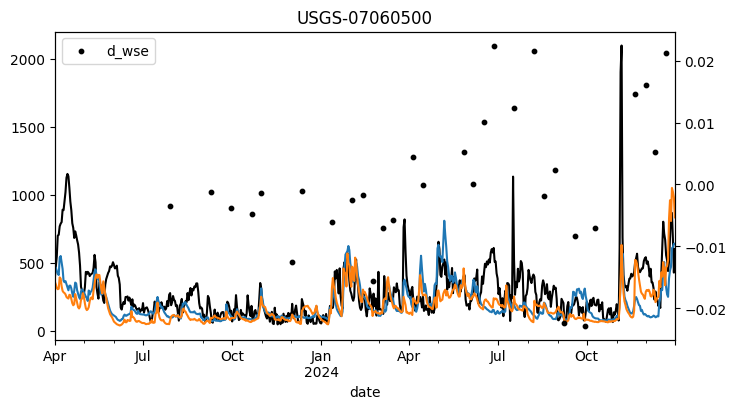

USGS-07032000: 31
ERA5: -1.09
ERA5 + SWOT: -1.54


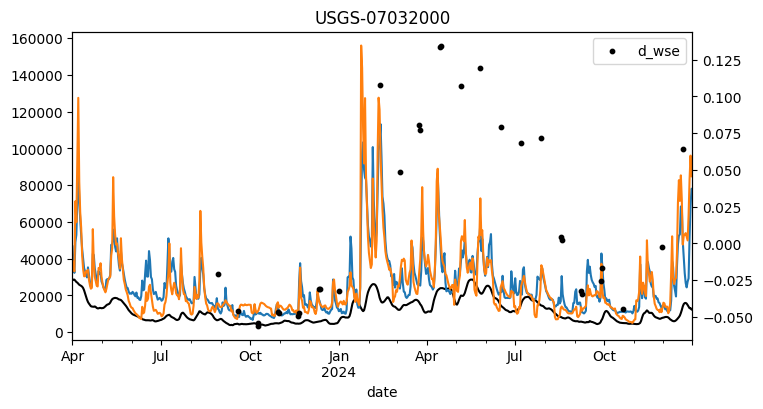

USGS-07260800: 29
ERA5: -1.64
ERA5 + SWOT: -1.45


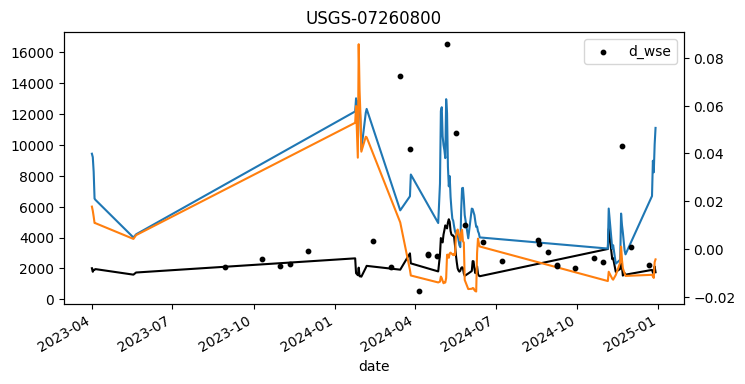

USGS-06888350: 29
ERA5: -6.92
ERA5 + SWOT: -3.87


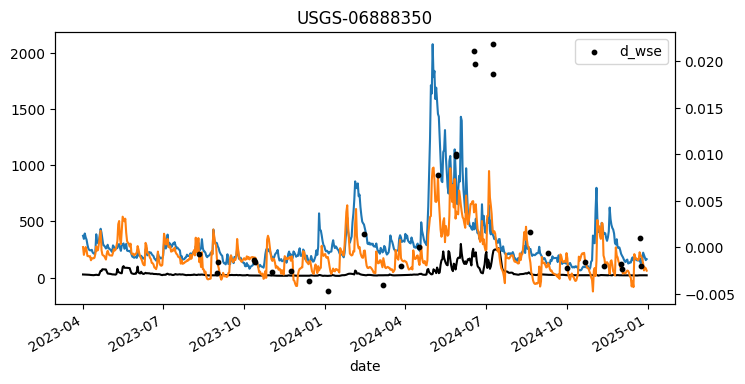

USGS-05446500: 28
ERA5: 0.64
ERA5 + SWOT: 0.26


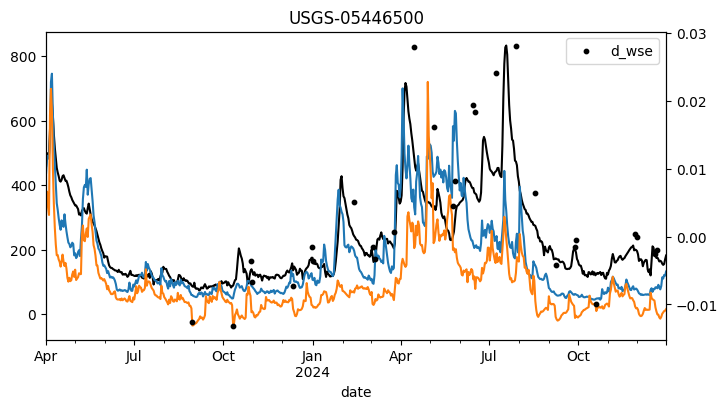

USGS-06856000: 26
ERA5: -20.18
ERA5 + SWOT: -10.29


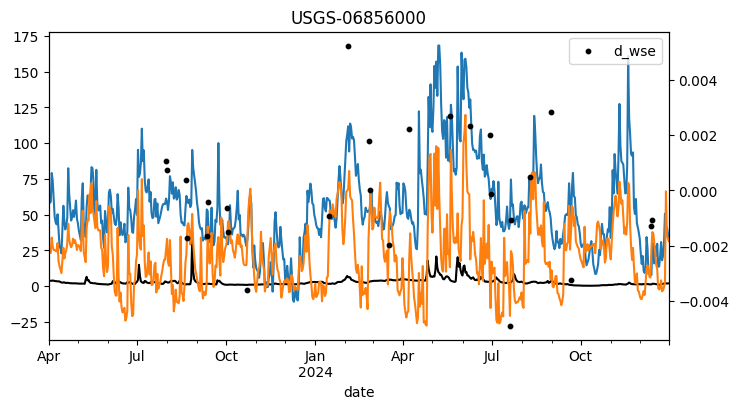

USGS-06759500: 26
ERA5: -0.14
ERA5 + SWOT: 0.13


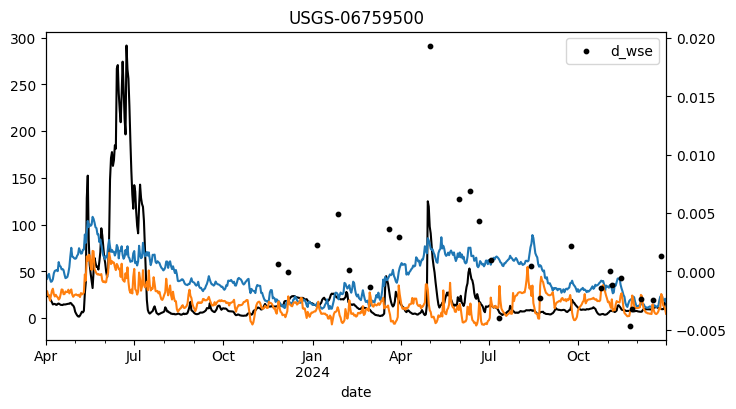

USGS-05437500: 26
ERA5: 0.71
ERA5 + SWOT: 0.73


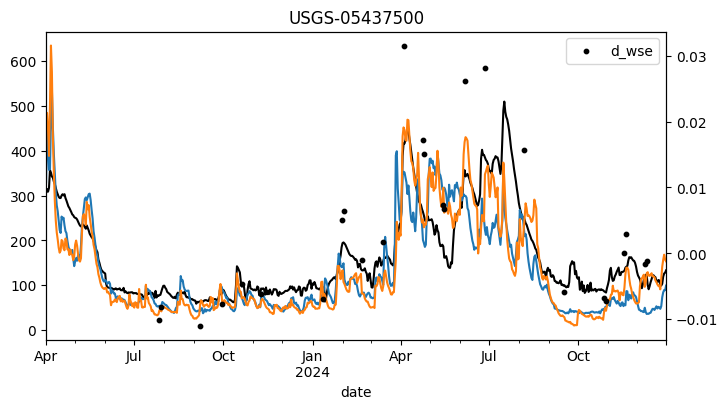

USGS-06207500: 26
ERA5: -0.00
ERA5 + SWOT: 0.09


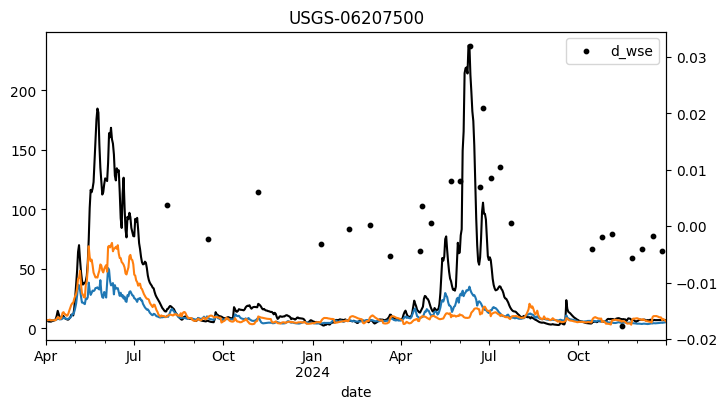

USGS-07194500: 25
ERA5: -1.36
ERA5 + SWOT: -0.14


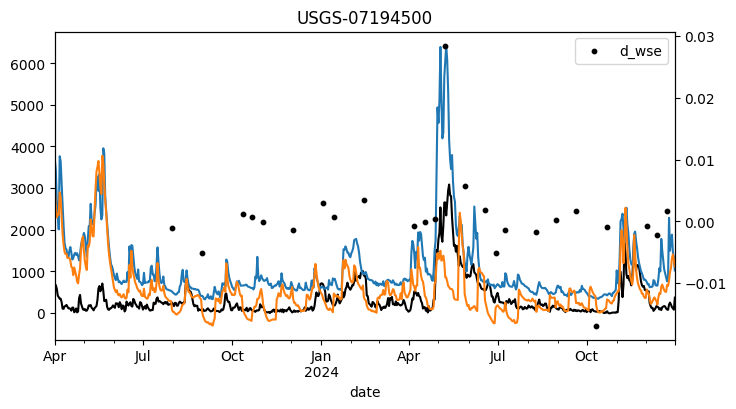

USGS-06607500: 24
ERA5: -0.03
ERA5 + SWOT: -0.07


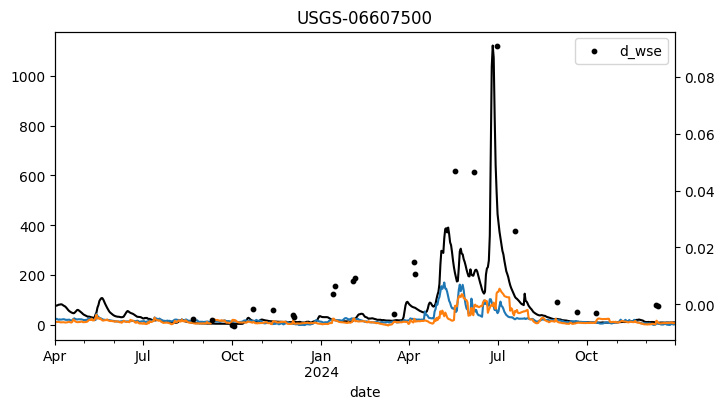

USGS-06065500: 24
ERA5: 0.58
ERA5 + SWOT: 0.42


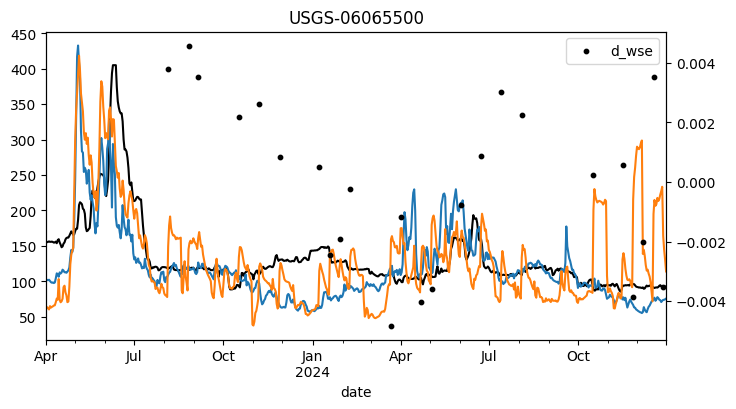

USGS-06102050: 23
ERA5: -1.06
ERA5 + SWOT: -0.92


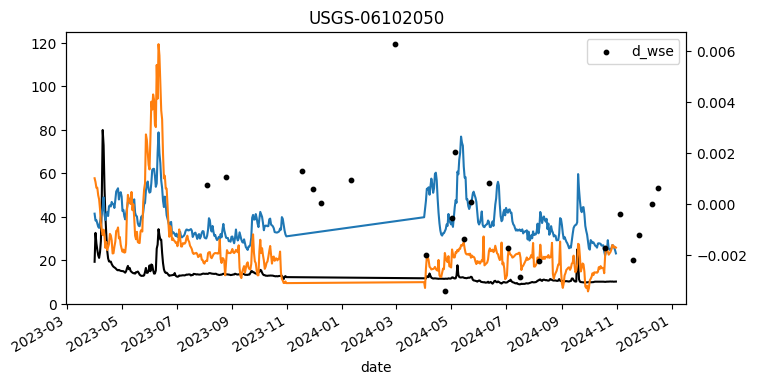

USGS-03185400: 23
ERA5: 0.71
ERA5 + SWOT: 0.55


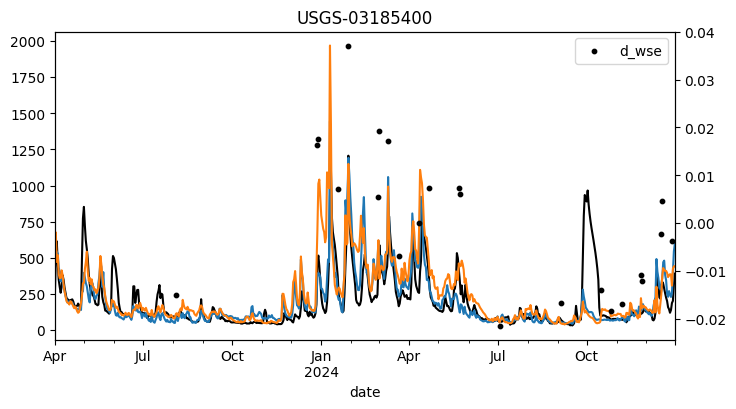

USGS-06294500: 23
ERA5: 0.23
ERA5 + SWOT: 0.24


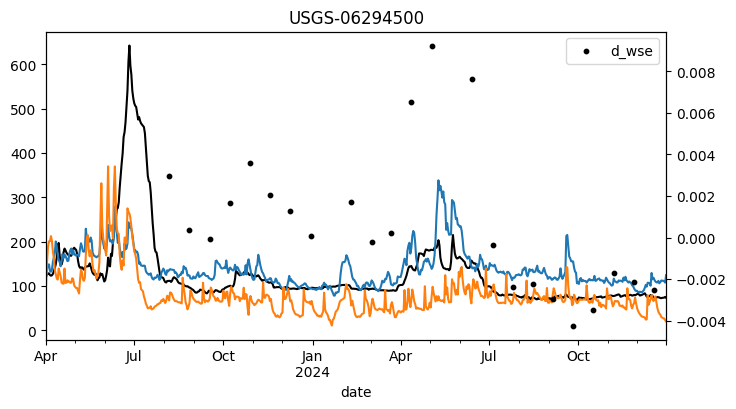

USGS-07191500: 22
ERA5: 0.48
ERA5 + SWOT: 0.44


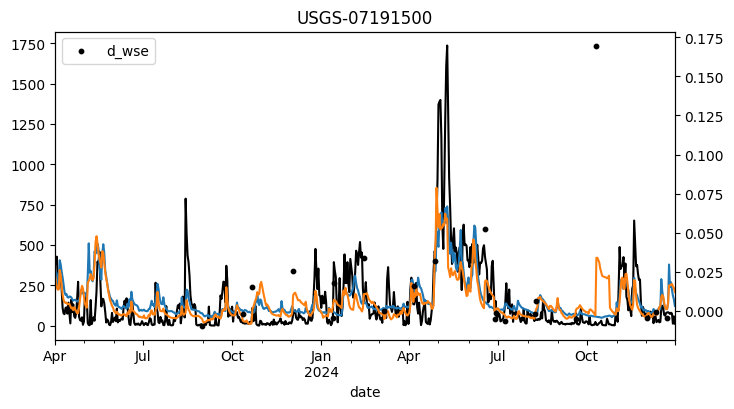

USGS-05283500: 22
ERA5: 0.82
ERA5 + SWOT: 0.69


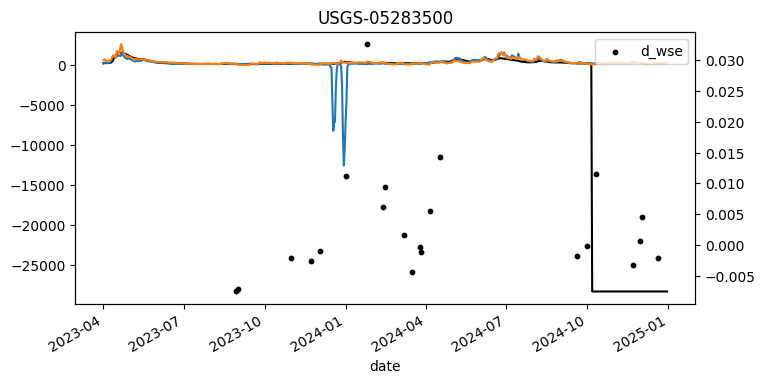

USGS-07249455: 22
ERA5: -1.97
ERA5 + SWOT: -2.29


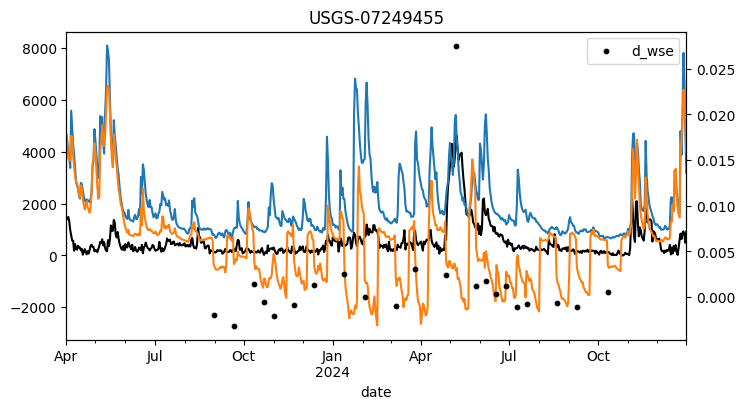

USGS-06115200: 21
ERA5: 0.21
ERA5 + SWOT: 0.13


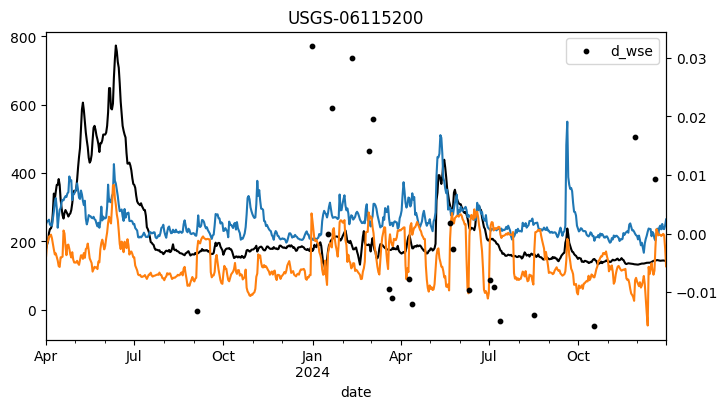

USGS-07138020: 21
ERA5: -35.46
ERA5 + SWOT: -12.83


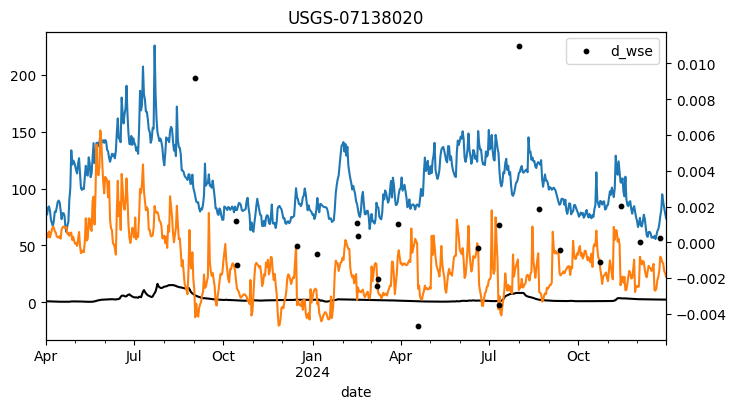

USGS-06041000: 19
ERA5: 0.47
ERA5 + SWOT: 0.36


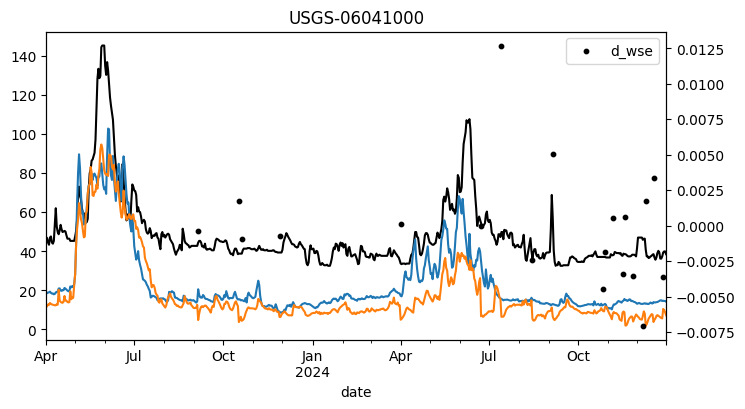

USGS-06208500: 19
ERA5: 0.05
ERA5 + SWOT: -0.03


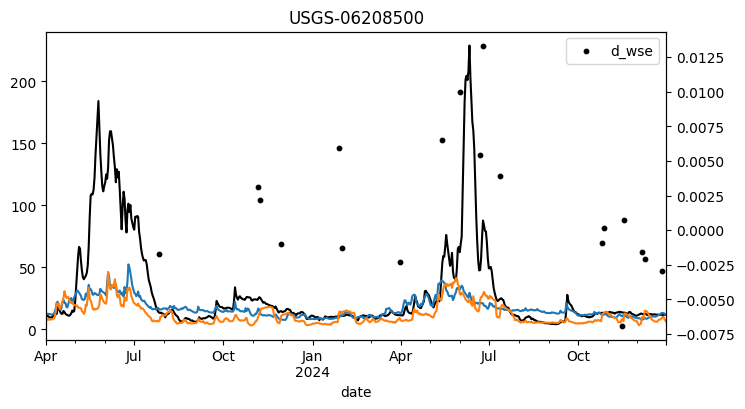

In [43]:
metric = 'KGE'
target='discharge'
start_date = '2023-01-01'
end_date = '2024-12-31'
colors = ['tab:blue','tab:orange']

ds = xr.open_zarr(f"/scratch4/workspace/tlanghorst_umass_edu-swot-ml-zarr/zbs_batched/{basin_id}")

for reach_id in gauge_swot_count.iloc[0:40].index:
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))

    print(f"{reach_id}: {gauge_swot_count.loc[reach_id].item()}")

    for (exp_name, results, bulk_metrics, basin_metrics), color in zip(exps, colors): 
        x = results.xs(reach_id, level='subbasin').sort_index()
        x = x.droplevel(0,0)
        x = x.loc[start_date:end_date]
        x['pred'][target].plot(ax=ax, color = color, label=exp_name)
        print(f"{exp_name}: {basin_metrics.loc[reach_id][target][metric]:0.2f}")

    x['obs'][target].plot(color='black', ax=ax, zorder=0, label='gauge')

    ax2 = ax.twinx()  # shares x axis but has its own y axis
    reach_ds = ds.sel(subbasin=reach_id, date=slice(start_date, end_date))
    date = reach_ds.date.values
    d_wse = reach_ds['d_wse_river'].values / 50
    ax2.scatter(date, d_wse, color='black', s=10, zorder=10, label='d_wse')
        
    
    plt.legend()
    plt.title(reach_id)
    plt.show()

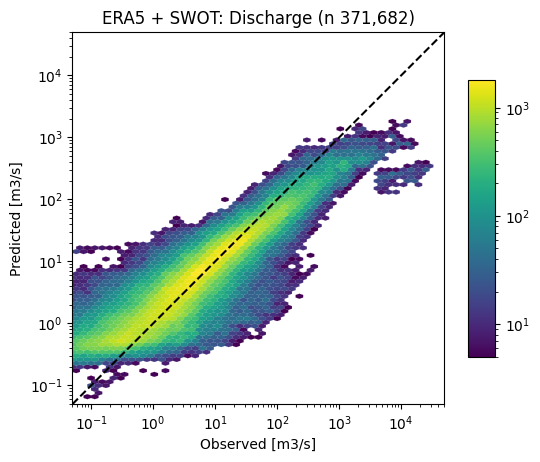

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

exp_idx = 1
name = exps[exp_idx][0]

x = exps[exp_idx][1]['obs'][target]
y = exps[exp_idx][1]['pred'][target]
positive_mask = (x > 0) & (y > 0)
x = x[positive_mask]
y = y[positive_mask]

min_val = 5E-2
max_val = 5E4
log_min = np.log10(min_val)
log_max = np.log10(max_val)

hb = ax.hexbin(x, y, gridsize=(50,50), bins='log', mincnt=5,
            linewidth=0.1,
            extent=(log_min, log_max, log_min, log_max),
            xscale='log', yscale='log')
plt.colorbar(hb, shrink=0.6, aspect=10, anchor=(0,0.5))

# Add a 1:1 line over the min and max of x and y
ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5)

# Setting axes to be square and equal range
ax.axis('square')
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.set_title(f"{name}: Discharge (n {len(x):,})")
ax.set_xlabel(f'Observed [m3/s]')
ax.set_ylabel(f'Predicted [m3/s]')
plt.show()

# fig.savefig(fig_dir / f"{name}_bulk_scatterplots.png", dpi=300)